### Исследование завсимости плотности от параметров НСВ

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts
import ipywidgets as widgets

#plt.style.use("default")

In [2]:

def show_pdf(pdf, xmin, xmax, grid_size, distr_name, **kwags):
    X = np.linspace(xmin, xmax, grid_size)
    Y = pdf(X, **kwags)
    ymax = max(Y) + 0.1
    plt.figure(figsize=(6, 3))
    plt.plot(X, Y, lw=5)
    plt.grid(ls=':')
    plt.xlabel('Значение', fontsize=10)
    plt.ylabel('Плотность', fontsize=10)
    plt.xlim(xmin, xmax)
    plt.ylim((-0.05, ymax))
    title = 'Плотность {}'.format(distr_name)
    plt.title(title.format(**kwags), fontsize=16)
    plt.show()



#### Равномерное распределение R(a, b):
Это распределение вероятностей, при котором каждое значение в интервале от a до b будет выбрано с равной вероятностью\
$$\varphi(x)=\frac{1}{b-a},\ x\in [a, b]$$

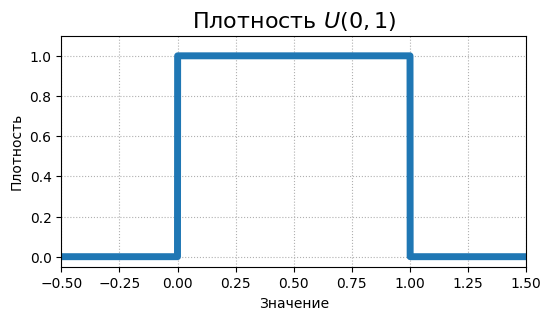

In [3]:
show_pdf(
    pdf=sts.uniform.pdf, xmin=-0.5, xmax=1.5, grid_size=10000,
    distr_name=r'$U(0, 1)$', loc=0, scale=1
)

In [4]:
ip = widgets.interactive(
    show_pdf,
    pdf=widgets.fixed(sts.uniform.pdf),
    grid_size=widgets.IntSlider(min=25, max=300, step=25,
                                 value=100, description='Число точек'),
    xmin=widgets.FloatSlider(min=-1.0, max=10.0, step=0.1,
                             value=1, description='Мин. значение'),
    xmax=widgets.FloatSlider(min=1.0, max=15.0, step=0.1,
                             value=10, description='Макс. значение'),
    loc=widgets.FloatSlider(min=1.0, max=15.0, step=0.1,
                             value=3, description='а'),
    scale=widgets.FloatSlider(min=0.5, max=10.0, step=0.01,
                             value=1, description='b - a'),
    distr_name=r'$U$({loc:.2f}, {loc:.2f} + {scale:.2f})',                         
);

display(widgets.VBox(ip.children[:2] + ip.children[4:]))



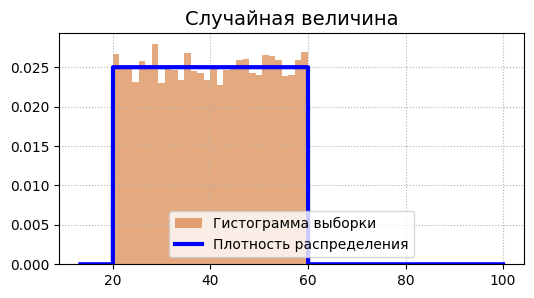

Математическое ожидание: 40.049, а по формуле: 40.0
Дисперсия: 135.077, а по формуле: 133.333


In [5]:
def plot_uniform(a=0, b=1, n_points=1000):
    plt.figure(figsize=(6, 3))
    sample = sts.uniform.rvs(loc=a, scale=b - a, size=n_points)

    plt.hist(sample, bins=30, density=True, color='#cc5500',
             alpha=0.5, label='Гистограмма выборки')
    grid = np.linspace(a - (b - a) / 6, b + (b - a), n_points)
    plt.plot(grid, sts.uniform.pdf(grid, a, b - a), color='blue',
             lw=3, label='Плотность распределения')
    
    plt.title(r'Случайная величина', fontsize=14)
    plt.legend(fontsize=10, loc=8)
    plt.grid(ls=':')
    plt.show()

    print(f'Математическое ожидание: {round(sample.mean(), 3)}, а по формуле: {round((a + b) / 2, 3)}')
    print(f'Дисперсия: {round(sample.var(), 3)}, а по формуле: {round(((b - a) ** 2) / 12, 3)}')

plot_uniform(20, 60, 10000)


#### Экспоненциальное распределение Exp(λ)
Это распределение вероятностей, которе используется для моделирования времени, в течение которого мы должны ждать, пока не произойдет определенное событие\
$$\varphi(x)=\lambda e^{-\lambda x},\ x\ge 0$$

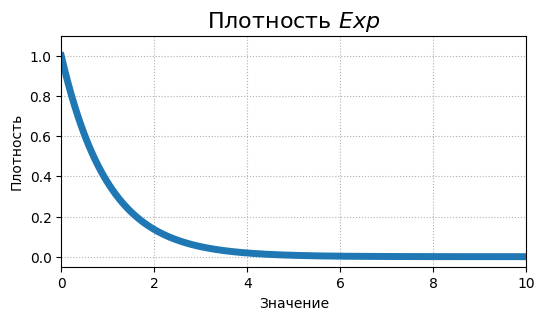

In [6]:
show_pdf(
    pdf=sts.expon.pdf, xmin=0, xmax=10, grid_size=10000,
    distr_name=r'$Exp$', scale=1
)

In [ ]:
ip = widgets.interactive(
    show_pdf,
    pdf=widgets.fixed(sts.expon.pdf),
    grid_size=widgets.IntSlider(min=25, max=300, step=25,
                                 value=100, description='Число точек'),
    xmin=widgets.FloatSlider(min=0, max=20.0, step=0.1,
                             value=0, description='Мин. значение'),
    xmax=widgets.FloatSlider(min=1.0, max=20.0, step=0.1,
                             value=10, description='Макс. значение'),
    scale=widgets.FloatSlider(min=0, max=5.0, step=0.01,
                             value=1, description='1/λ'),
    distr_name=r'$Exp$({scale:.2f})',                         
);

display(widgets.VBox(ip.children[:2] + ip.children[4:]))


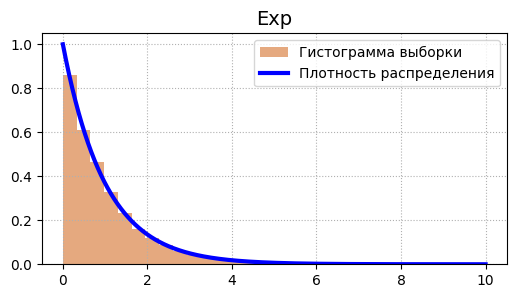

Математическое ожидание: 0.983, а по формуле: 1
Дисперсия: 0.942, а по формуле: 1


In [8]:
def plot_exp(lmbd=1, n_points=10000):
    plt.figure(figsize=(6, 3))
    sample = sts.expon.rvs(scale=1/lmbd, size=n_points)

    plt.hist(sample, bins=30, density=True, color='#cc5500',
             alpha=0.5, label='Гистограмма выборки')
    grid = np.linspace(0, 10, n_points)
    plt.plot(grid, sts.expon.pdf(grid, scale=1/lmbd), color='blue',
             lw=3, label='Плотность распределения')
    
    plt.title(r'Exp', fontsize=14)
    plt.legend(fontsize=10, loc=0)
    plt.grid(ls=':')
    plt.show()

    print(f'Математическое ожидание: {round(sample.mean(), 3)}, а по формуле: {round(lmbd, 3)}')
    print(f'Дисперсия: {round(sample.var(), 3)}, а по формуле: {round(lmbd, 3)}')

plot_exp()


#### Нормальное распределение N(a, σ^2)

С этим распределением связана важнейшая Центральная предельная теорема, котора гласит, что если величина является суммой многих случайных слабо взаимосвязанных величин, каждая из которых вносит малый вклад относительно общей суммы, то центрированное и нормированное распределение такой веричины при достаточно большом числе слагаемых стремится к нормальному распределению\
$$\varphi(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{\frac{^{-(x-a)^{2}}}{2\sigma^{2}}}$$

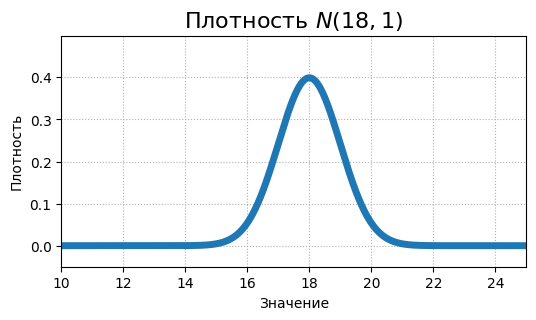

In [9]:
show_pdf(
    pdf=sts.norm.pdf, xmin=10, xmax=25, grid_size=10000,
    distr_name=r'$N(18, 1)$', loc=18, scale=1
)

In [ ]:
ip = widgets.interactive(
    show_pdf,
    pdf=widgets.fixed(sts.norm.pdf),
    grid_size=widgets.IntSlider(min=25, max=300, step=25,
                                 value=100, description='Число точек'),
    xmin=widgets.FloatSlider(min=-1.0, max=10.0, step=0.1,
                             value=0, description='Мин. значение'),
    xmax=widgets.FloatSlider(min=5.0, max=25.0, step=0.1,
                             value=15, description='Макс. значение'),
    loc=widgets.FloatSlider(min=-1.0, max=25.0, step=0.1,
                             value=10, description='а'),
    scale=widgets.FloatSlider(min=0.01, max=10.0, step=0.01,
                             value=1, description='b - a'),
    distr_name=r'$N$({loc:.2f}, {scale:.2f})',                         
);

display(widgets.VBox(ip.children[:2] + ip.children[4:]))


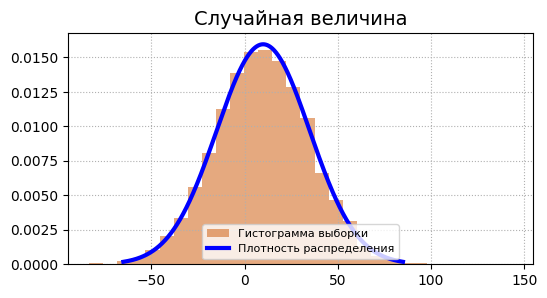

Математическое ожидание: 9.578, а по формуле: 10
Дисперсия: 627.477, а по формуле: 625


In [11]:
def plot_norm(a=0, sigma=1, n_points=10000):
    plt.figure(figsize=(6, 3))
    sample = sts.norm.rvs(loc=a, scale=sigma, size=n_points)

    plt.hist(sample, bins=30, density=True, color='#cc5500',
             alpha=0.5, label='Гистограмма выборки')
    grid = np.linspace(a - 3 * sigma, a + 3 * sigma, n_points)
    plt.plot(grid, sts.norm.pdf(grid, a, sigma), color='blue',
             lw=3, label='Плотность распределения')
    
    plt.title(r'Случайная величина', fontsize=14)
    plt.legend(fontsize=8, loc=8)
    plt.grid(ls=':')
    plt.show()

    print(f'Математическое ожидание: {round(sample.mean(), 3)}, а по формуле: {round(a, 3)}')
    print(f'Дисперсия: {round(sample.var(), 3)}, а по формуле: {round(sigma ** 2, 3)}')

plot_norm(10, 25)


## Самостоятельное исследование

### Распределение Фишера-Снедекора

Распределением Фишера-Снедекора или F-распределением называется распределение случайной величины (1), где $\chi^{2}(k_{1})$ и $\chi^{2}(k_{2})$ - случайные величины, имеющие $\chi^{2}$-распределение с соответственно с $k_{1}$ и $k_{2}$ степенями свободы.

$$F=\frac{\frac{1}{k_1}\chi^{2}(k_1)}{\frac{1}{k_2}\chi^{2}(k_2)}(1)$$
Плотность вероятности F-распределения имеет вид:
$$\varphi(x)=\frac{\Gamma(\frac{k_1+k_2}{2}k_1^{^{\frac{k_1}{2}}}k_2^{\frac{k2}{2}})}{\Gamma(\frac{k1}{2})\Gamma(\frac{k_2}{2})}x^{\frac{k_1}{2}-1}(k_1x+k_2)^{-\frac{k_1+k_2}{2}}$$
Где Г(у) - это гамма функция Эйлера в точке у\
Математическое распределение и дисперсия случайно величины, имеющих данное распределение имеют вид:
$$M(x)=\frac{k_2}{k_2-2}, \text{  Если } k_2>2$$
$$D(x)=\frac{2k_2^{2}(k_1+k_2-2)}{k_1(k_2-2)^{2}(k_2-4)},\text{ Если }k_2>4$$

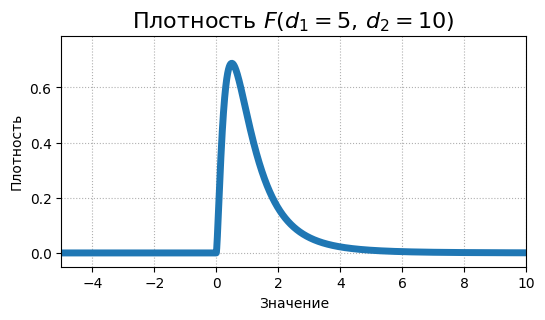

In [ ]:
show_pdf(
    pdf=sts.f.pdf, xmin=-5, xmax=10, grid_size=10000,
    distr_name=r'$F(d_1={dfn},\, d_2={dfd})$', dfn=5, dfd=10
)

In [ ]:
ip = widgets.interactive(
    show_pdf,
    pdf=widgets.fixed(sts.f.pdf),

    grid_size=widgets.IntSlider(min=100, max=5000, step=100, value=1000, description='Число точек'),
    xmin=widgets.FloatSlider(min=0.0, max=5.0, step=0.1, value=0.0, description='Мин. значение'),
    xmax=widgets.FloatSlider(min=1.0, max=30.0, step=0.5, value=10.0, description='Макс. значение'),
    dfn=widgets.IntSlider(min=1, max=30, step=1, value=5, description='d₁'),
    dfd=widgets.IntSlider(min=3, max=50, step=1, value=10, description='d₂'),
    distr_name=widgets.fixed(''),
)

display(widgets.VBox(ip.children[:2] + ip.children[3:]))


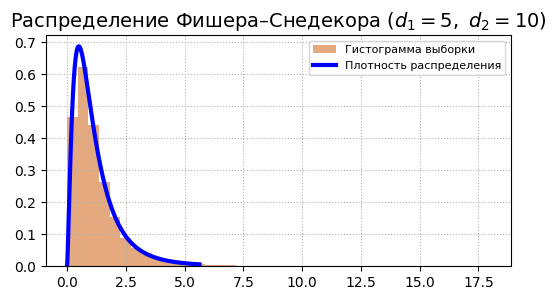

Математическое ожидание: 1.243, а по формуле: 1.250
Дисперсия: 1.314, а по формуле: 1.354


In [14]:
def plot_fisher(k1=5, k2=10, n_points=10000):
    
    plt.figure(figsize=(6, 3))
    sample = sts.f.rvs(k1, k2, size=n_points)
    plt.hist(sample, bins=40, density=True, color='#cc5500',
             alpha=0.5, label='Гистограмма выборки')
    x_max = sts.f.ppf(0.99, k1, k2)
    grid = np.linspace(0, x_max, n_points)
    plt.plot(grid, sts.f.pdf(grid, k1, k2), color='blue', lw=3,
             label='Плотность распределения')
    plt.title(rf'Распределение Фишера–Снедекора ($d_1={k1},\ d_2={k2}$)', fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(ls=':')
    plt.show()
    mean_theory = k2 / (k2 - 2) if k2 > 2 else np.nan
    var_theory = (
        2 * k2**2 * (k1 + k2 - 2) / (k1 * (k2 - 2)**2 * (k2 - 4))
        if k2 > 4 else np.nan
    )
    print(f'Математическое ожидание: {sample.mean():.3f}, а по формуле: {mean_theory:.3f}')
    print(f'Дисперсия: {sample.var():.3f}, а по формуле: {var_theory:.3f}')


# пример вызова
plot_fisher(k1=5, k2=10)